In [1]:
import sys
sys.path.append("../")

import os
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"

%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import numpy as np
import arviz as az
import mpltern
import corner
import pickle
import logging

from utils.cart import to_cart

In [3]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

In [4]:
jax.devices()

[StreamExecutorGpuDevice(id=0, process_index=0, slice_index=0),
 StreamExecutorGpuDevice(id=1, process_index=0, slice_index=0)]

In [5]:
default_expand_keys = {
    'theta_bulge_poiss' : ['theta_mcdermott2022', 'theta_mcdermott2022_bbp', 'theta_mcdermott2022_x',
                           'theta_macias2019', 'theta_coleman2019'],
    'theta_ics'    : ['theta_MO_ics', 'theta_MA_ics', 'theta_MF_ics'],
    'theta_pibrem' : ['theta_MO_pib', 'theta_MA_pib', 'theta_MF_pib'],
}

def expand_samples(samples, expand_keys=default_expand_keys, conversion_func=(lambda x: x)):
    
    samples_new = {}
    for k in samples.keys():
        if k in expand_keys.keys():
            for i in range(samples[k].shape[-1]):
                samples_new[expand_keys[k][i]] = conversion_func(samples[k][...,i])
        else:
            samples_new[k] = conversion_func(samples[k])
            
    return samples_new

## 1. single run

In [6]:
from models.np_model import NPModel

In [7]:
pmodel = NPModel(
    r_outer=25,
    l_max=1,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
    non_poissonian=False
)

In [8]:
svi_results = pmodel.fit_svi(rng_key=jax.random.PRNGKey(42),
                             n_steps=7500,
                             guide="iaf_mixture",
                             lr=1e-4)

100%|████████████████████| 7500/7500 [00:28<00:00, 264.42it/s, init loss: 89151.0629, avg. loss [7126-7500]: 20224.8218]


In [11]:
posterior = pmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42),
                                         num_samples=50000)
posterior = expand_samples(posterior)

In [17]:
saddle_map_svi_results = pmodel.get_MAP_estimates(rng_key=jax.random.PRNGKey(1), n_steps=100, lr=0.1)
saddle_map_estimates = expand_samples(pmodel.MAP_estimates, conversion_func=float)
map_svi_results = pmodel.get_MAP_estimates(rng_key=jax.random.PRNGKey(1), n_steps=30000, lr=0.1)
map_estimates = expand_samples(pmodel.MAP_estimates, conversion_func=float)

100%|████████████████| 30000/30000 [00:38<00:00, 774.46it/s, init loss: 34855.4692, avg. loss [28501-30000]: 17830.2187]


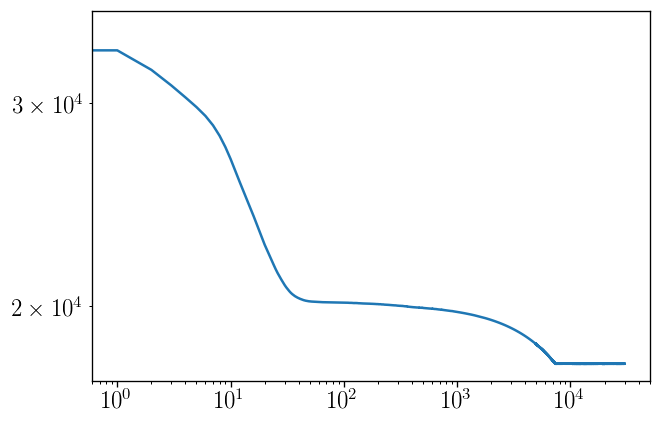

In [10]:
plt.plot(map_svi_results.losses)
plt.loglog();

In [ ]:
az.summary(posterior)

In [ ]:
ax = plt.subplot(projection='ternary')
ax.hist2d(*posterior_bulge['theta_pibrem'].T, cmap='Reds', bins=100, vmax=10, density=True)
ax.set(aspect=0.8)

In [ ]:
posterior_pibrem = {}
for i in range(3):
    posterior_pibrem[str(i)] = posterior_bulge['theta_pibrem'][:, i]
az.summary(az.from_dict(posterior_pibrem))

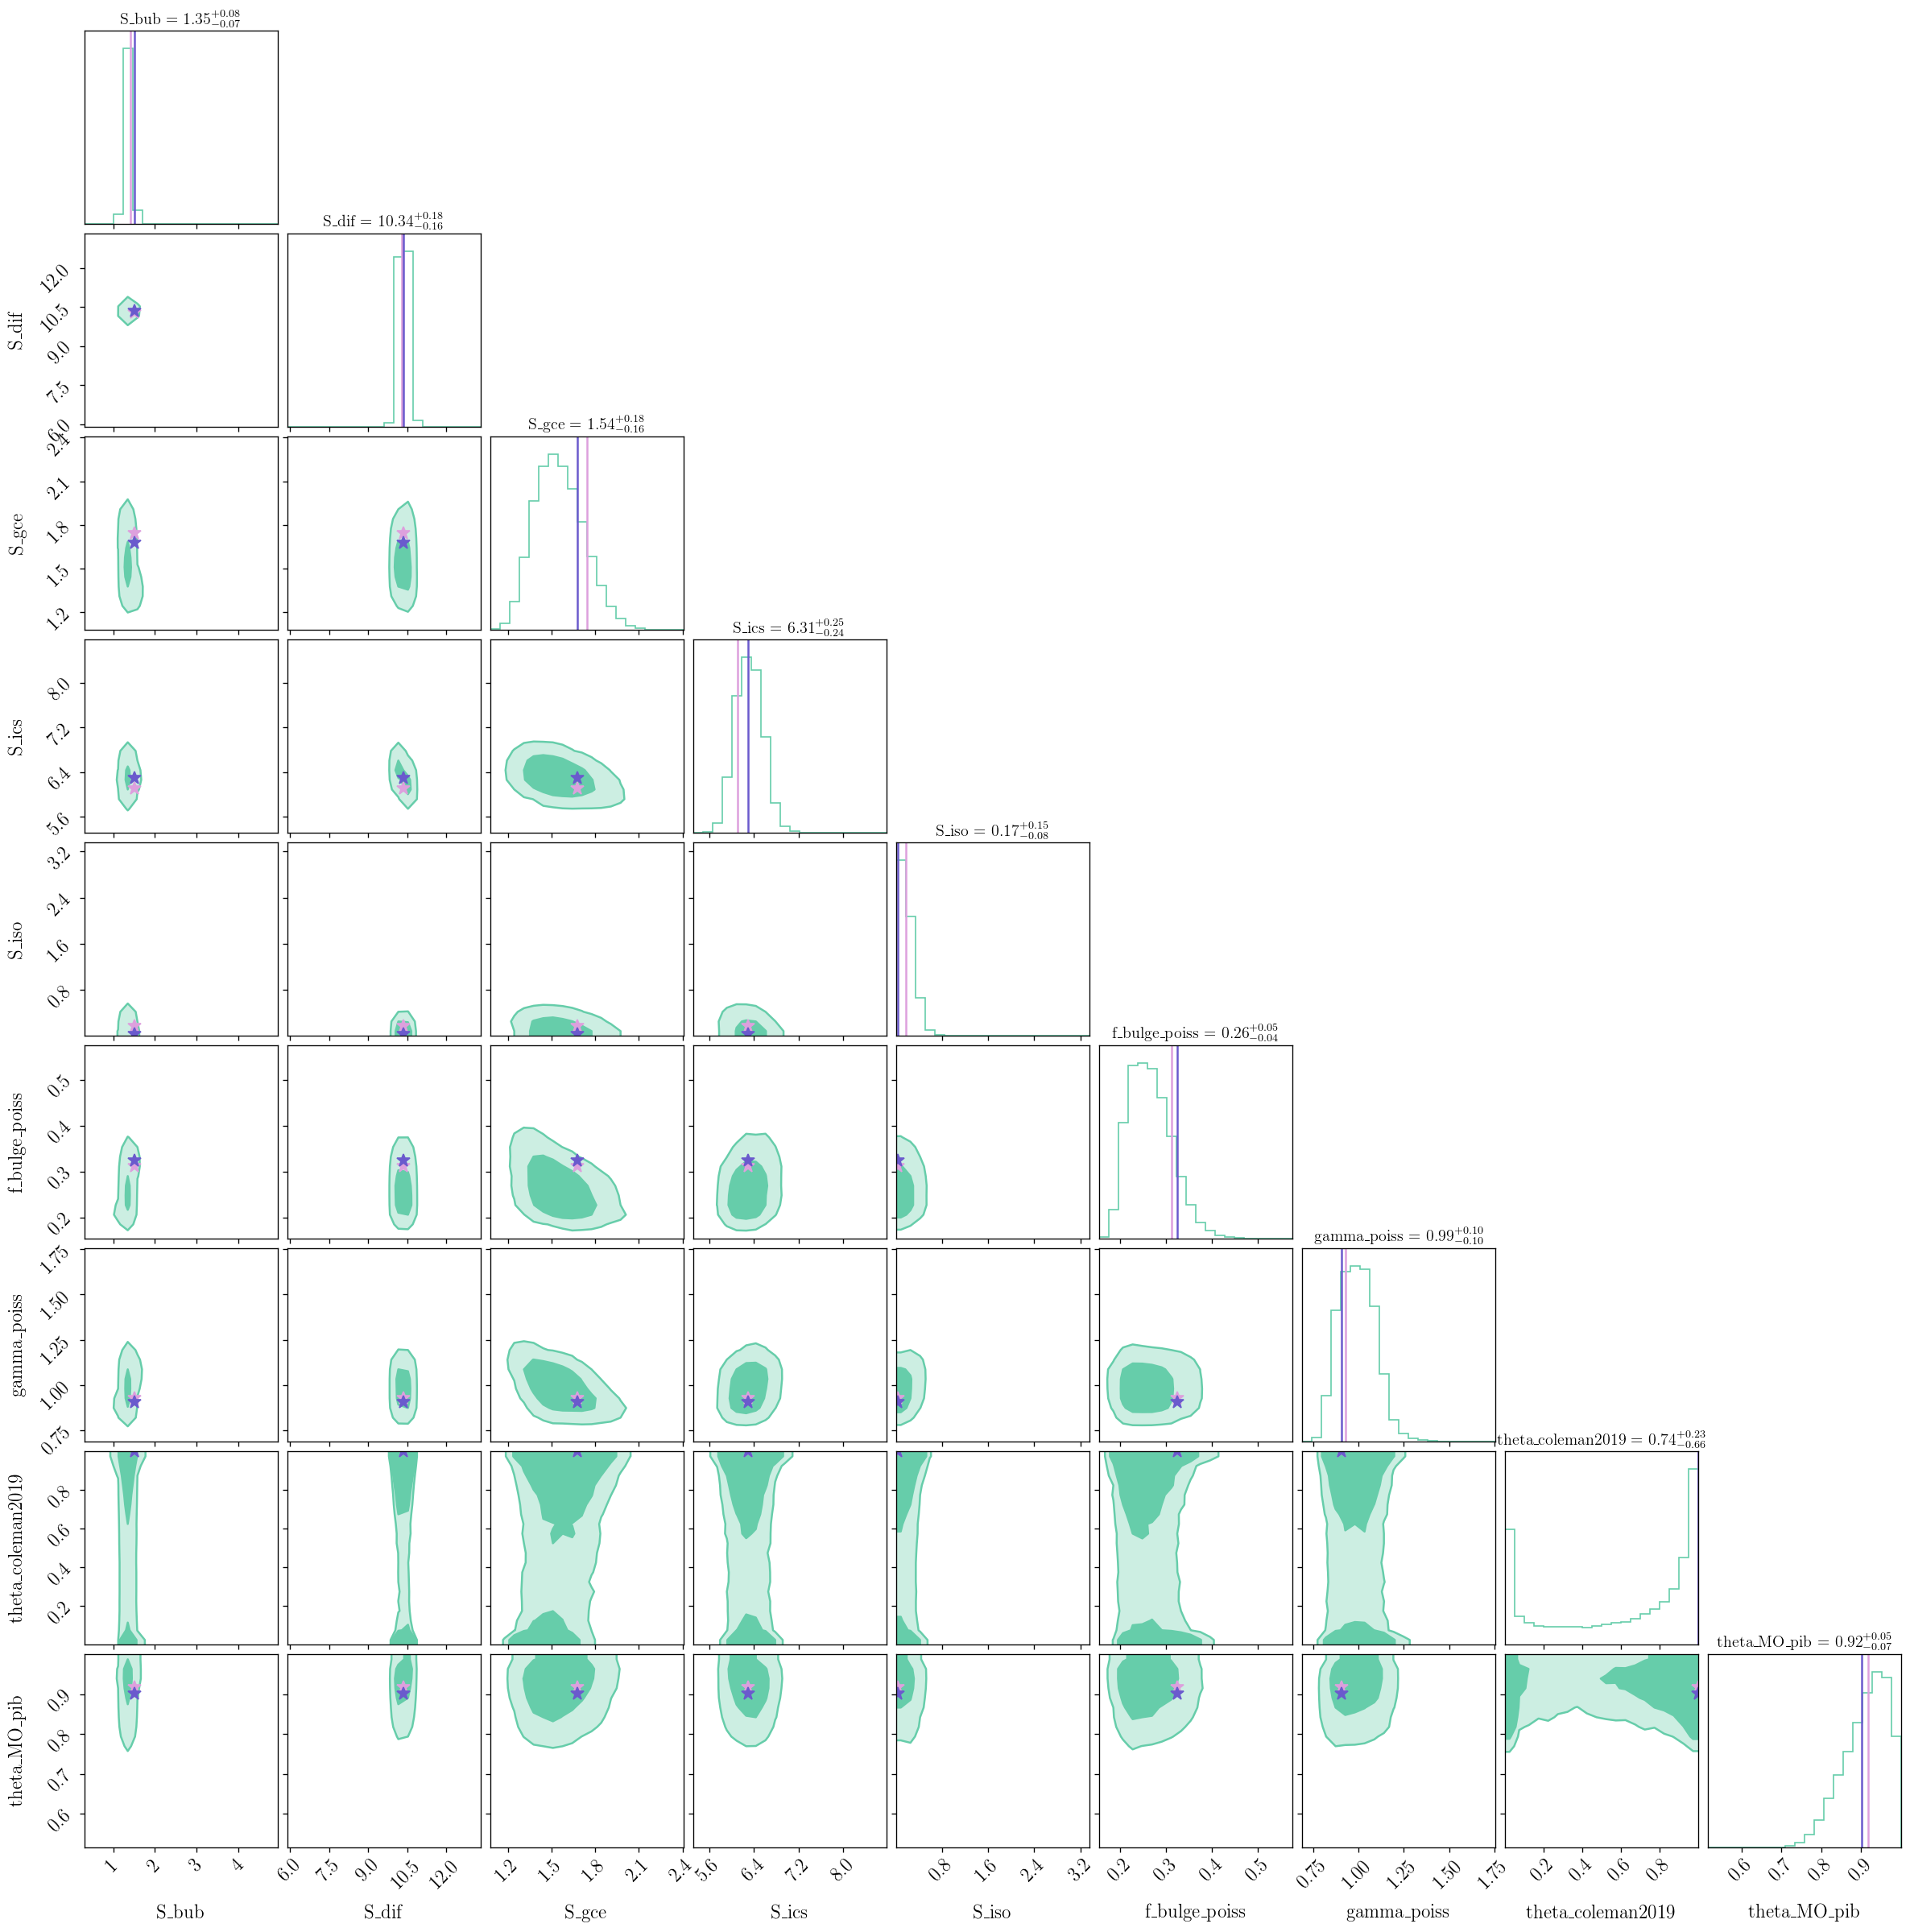

In [18]:
vs = ['S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso',
      'f_bulge_poiss', 'gamma_poiss', 'theta_coleman2019',
      'theta_MO_pib']

figure = corner.corner(
    posterior,
    var_names=vs,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    levels = [0.68, 0.95],
    color = 'mediumaquamarine',
    plot_contours=True,
    fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
)

ndim = len(vs)
axs = np.array(figure.axes).reshape((ndim, ndim))

for i, v in enumerate(vs):
    axs[i,i].axvline(saddle_map_estimates[v], color='plum')
    axs[i,i].axvline(map_estimates[v], color='slateblue')
    
for ri in range(ndim):
    for ci in range(ri):
        axs[ri,ci].plot(map_estimates[vs[ci]], saddle_map_estimates[vs[ri]], '*', color='plum', ms=10)
        axs[ri,ci].plot(map_estimates[vs[ci]], map_estimates[vs[ri]], '*', color='slateblue', ms=10)

## 2. vary masks

In [6]:
from models.np_model import NPModel

In [9]:
mask_bs = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
nside = 256
#ps_cat = "4fgl"
#bulge_names = ['mcdermott2022', 'mcdermott2022_bbp', 'mcdermott2022_x', 'macias2019', 'coleman2019']
SAVE_DIR = '../data/posteriors/vary_disk_mask'

#for bulge_name in bulge_names:
for ps_cat in ["4fgl"]:
    for mask_b in mask_bs:

        pmodel = NPModel(
            non_poissonian=False,
            #bulge_template_names=[bulge_name],
            l_max=1,
            vary_gamma=True,
            bulge_hybrid=True,
            ps_cat=ps_cat,
            r_outer=25,
            band_mask_range=mask_b,
            nside=nside,
        )
        #========== SVI ==========
        svi_results = pmodel.fit_svi(
            rng_key=jax.random.PRNGKey(42),
            n_steps=5000,
            guide="iaf_mixture",
            lr=1e-4
        )
        posterior = pmodel.get_posterior_samples(
            rng_key=jax.random.PRNGKey(42),
            num_samples=50000
        )
        # expand_keys = {
        #     'theta_ics'    : ['theta_MO_ics', 'theta_MA_ics', 'theta_MF_ics'],
        #     'theta_pibrem' : ['theta_MO_pib', 'theta_MA_pib', 'theta_MF_pib'],
        # }
        posterior = expand_samples(posterior)

        #========== MAP ==========
        map_svi_results = pmodel.get_MAP_estimates(rng_key=jax.random.PRNGKey(42), n_steps=30000, lr=0.02)
        map_estimates = expand_samples(pmodel.MAP_estimates, conversion_func=float)

        #========== save ==========
        #fn = f'{SAVE_DIR}/b{mask_b:.1f}_nside{nside}_psc{ps_cat}_bulge{bulge_name}.p'
        fn = f'{SAVE_DIR}/b{mask_b:.1f}_nside{nside}_psc{ps_cat}_hybrid.p'
        save_dict = {
            'posterior' : posterior,
            'svi_results' : svi_results,
            'map_estimates' : map_estimates,
        }
        pickle.dump(save_dict, open(fn, 'wb'))

100%|███████████████| 30000/30000 [01:49<00:00, 273.84it/s, init loss: 210807.9931, avg. loss [28501-30000]: 55593.6844]


### 2.1 compare

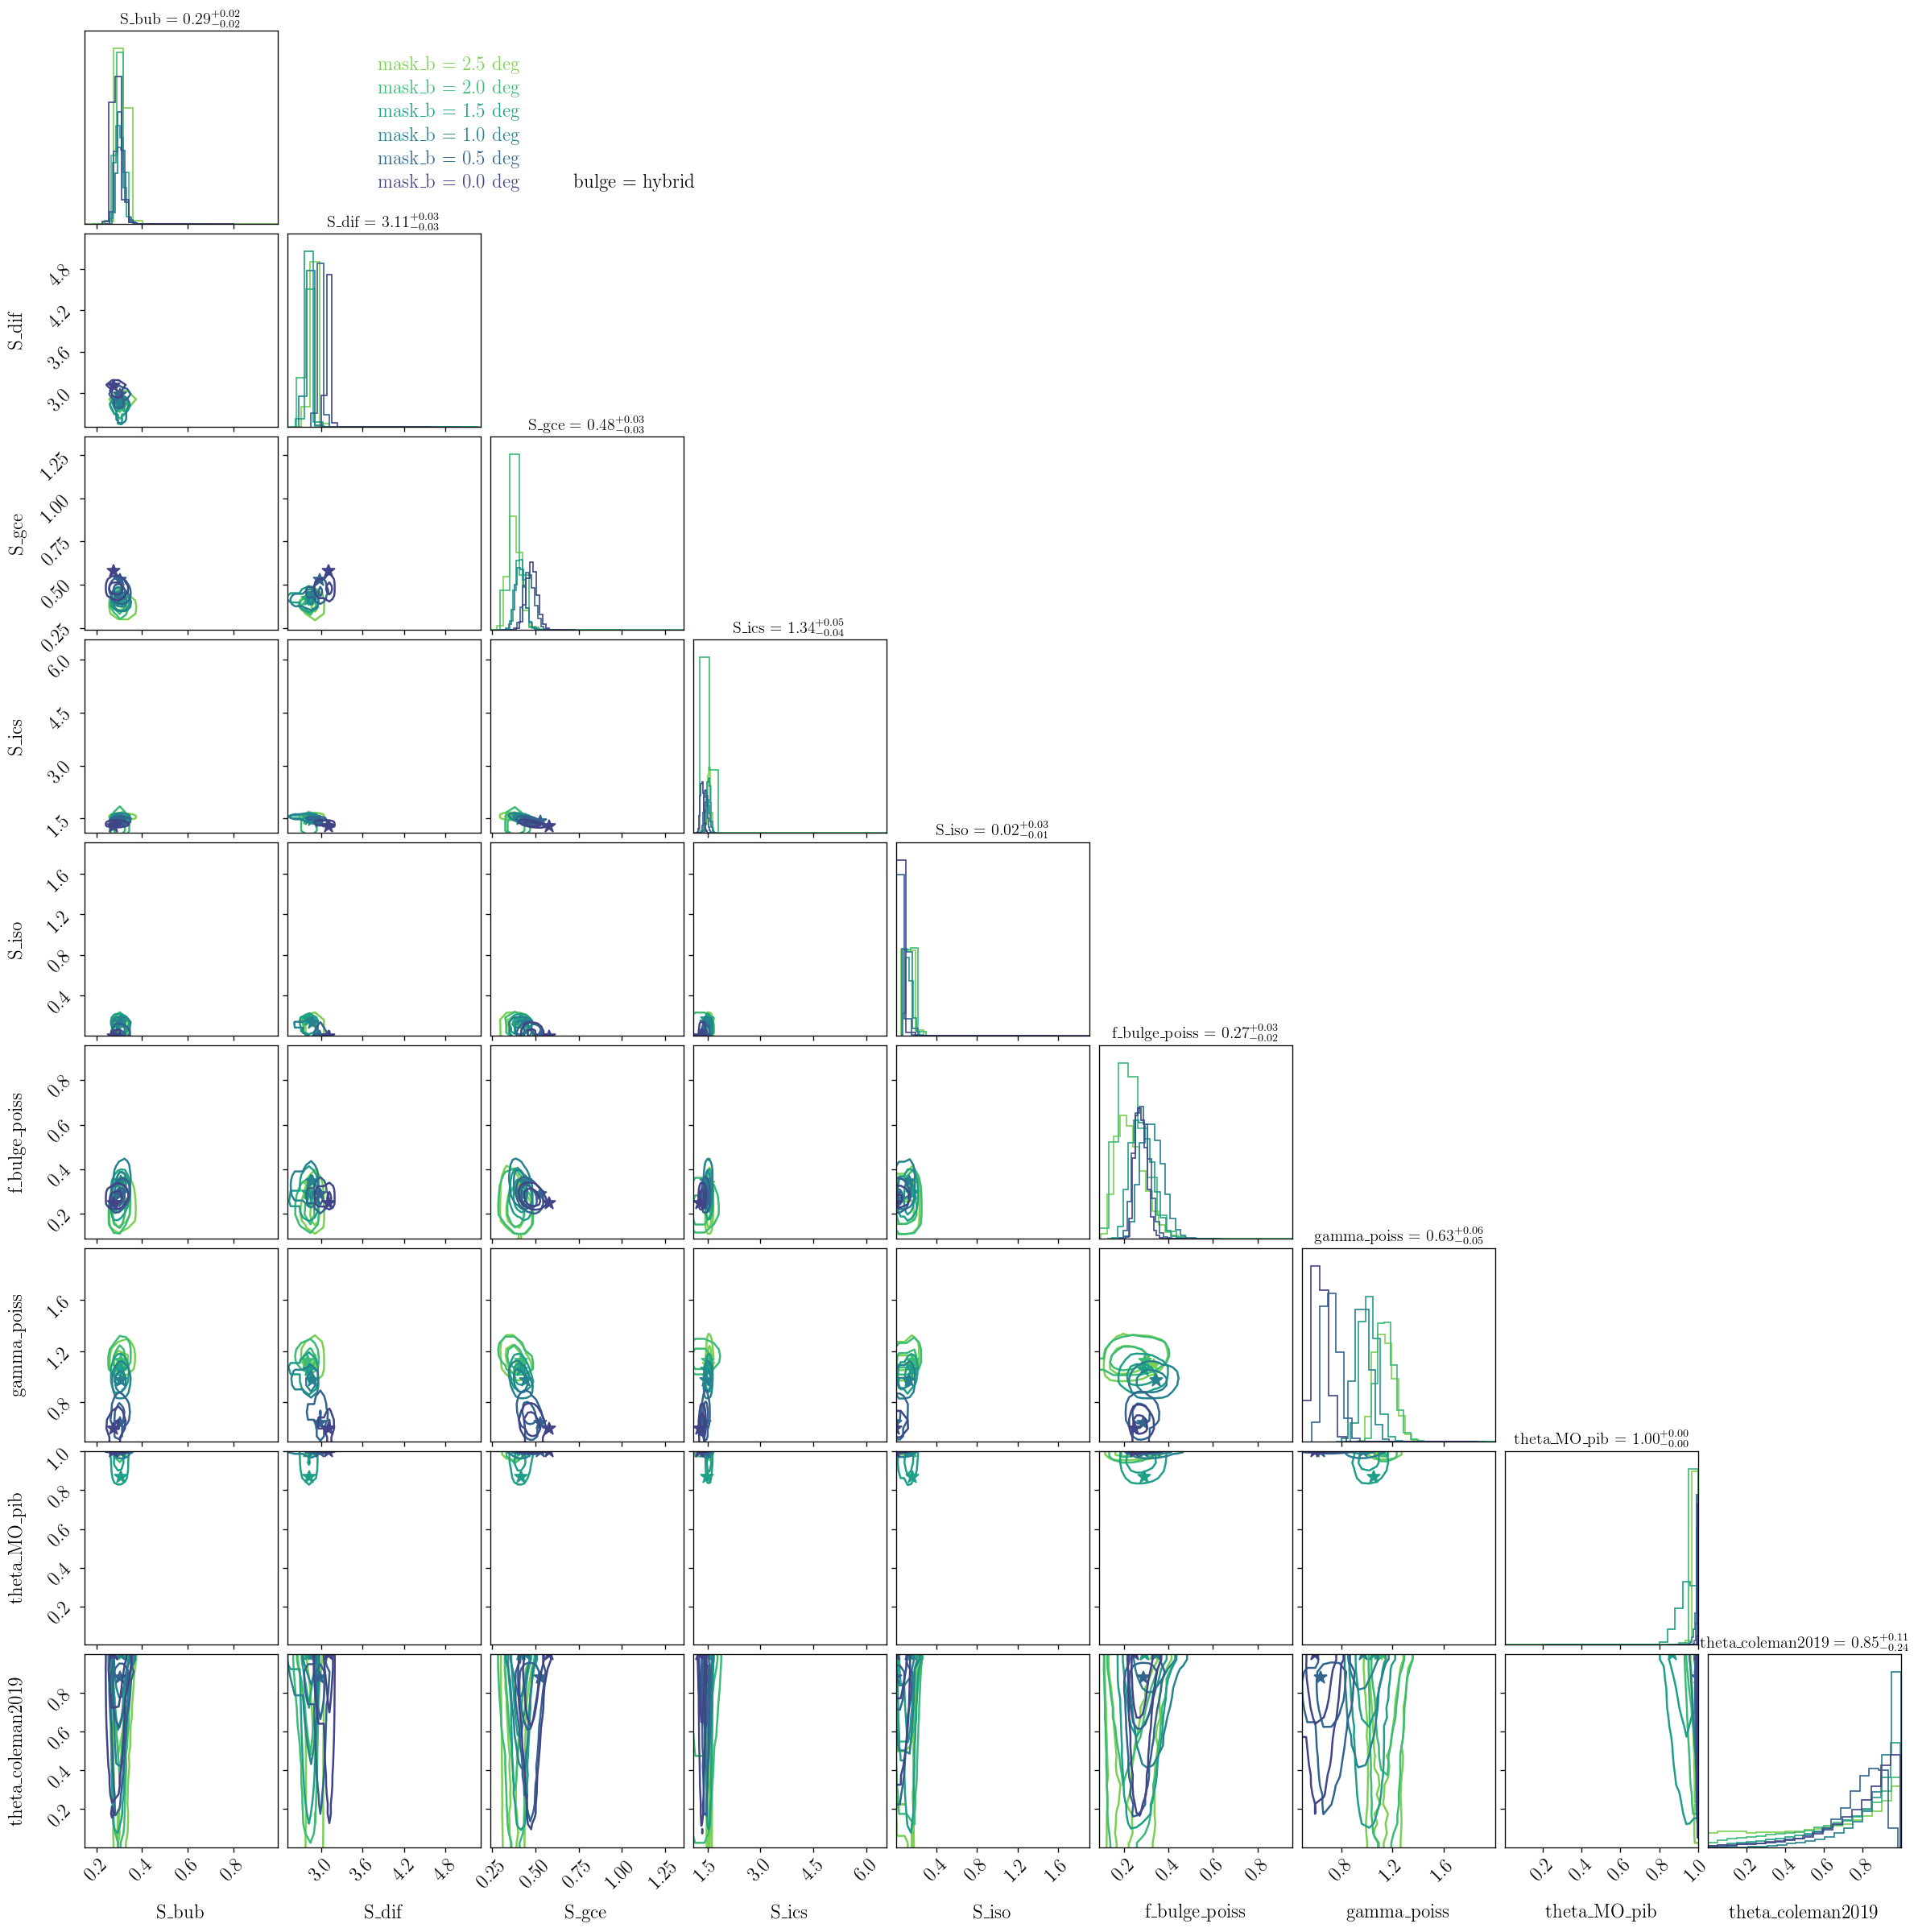

In [10]:
mask_bs = [0, 0.5, 1, 1.5, 2, 2.5]
nside = 256
ps_cat = "4fgl"
# mcdermott2022 mcdermott2022_bbp mcdermott2022_x macias2019 coleman2019
#bulge_option = 'bulge' + 'mcdermott2022'
bulge_option = 'hybrid'
DATA_DIR = '../data/posteriors/vary_disk_mask'

colors = {
    'single' : [mpl.colors.to_hex(mpl.cm.get_cmap('viridis')(x))  for x in np.linspace(0.2, 0.8, len(mask_bs))],
    '3fgl' : [mpl.colors.to_hex(mpl.cm.get_cmap('Blues')(x))  for x in np.linspace(1, 0.2, len(mask_bs))],
    '4fgl' : [mpl.colors.to_hex(mpl.cm.get_cmap('Greens')(x)) for x in np.linspace(1, 0.2, len(mask_bs))],
}

figure = None
#for c in ['3fgl']:
for i, mask_b in reversed(list(enumerate(mask_bs))):
    result = pickle.load(open(f'{DATA_DIR}/b{mask_b:.1f}_nside{nside}_psc{ps_cat}_{bulge_option}.p', 'rb'))
    #print(np.mean(sample['svi_results'].losses[-100:]))

    vs = ['S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso', 'f_bulge_poiss', 'gamma_poiss', 'theta_MO_pib', 'theta_coleman2019']
    figure = corner.corner(
        result['posterior'],
        var_names=vs,
        show_titles=True,
        title_kwargs={"fontsize": 12},
        levels = [0.68, 0.95],
        color = colors['single'][i],
        plot_contours=True,
        fill_contours=False,
        plot_density=False,
        plot_datapoints=False,
        fig=figure
    )
    ndim = len(vs)
    axs = np.array(figure.axes).reshape((ndim, ndim))

    # for di, v in enumerate(vs):
    #     axs[di,di].axvline(result['map_estimates'][v], color=colors['MAP'][i])

    for ri in range(ndim):
        for ci in range(ri):
            axs[ri,ci].plot(result['map_estimates'][vs[ci]], result['map_estimates'][vs[ri]], '*', color=colors['single'][i], ms=10)

    figure.text(0.2, 0.9+0.012*i, f"mask_b = {mask_b:.1f} deg", fontsize=14, color=colors['single'][i])
        
figure.text(0.3, 0.9, f"bulge = {bulge_option.split('bulge')[-1]}", fontsize=14, color='k')

plt.savefig(f'{bulge_option}_{ps_cat}.pdf')

## 3. Scan

In [ ]:
import numpy as np
import pickle

ps_cat = "3fgl"
r_outer = 25
nside = 128

# for nside in [128]:
#     for config in ["000","100","110","111"]:
#         for l_max in [0, 3]:
for ps_cat in ["3fgl"]:
    for config in ["-00", "-01", "-10", "-11"]:
        for l_max in [0]:

            vary_gamma = int(config[1])
            bulge_hybrid = int(config[2])

            pmodel = PoissonModel(r_outer=r_outer, l_max=l_max, vary_gamma=vary_gamma, bulge_hybrid=bulge_hybrid, ps_cat=ps_cat, nside=nside)
            svi_results = pmodel.fit_svi(rng_key=jax.random.PRNGKey(np.random.randint(1000)), n_steps=20000, guide="iaf", lr=2e-4)

            posterior = pmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(np.random.randint(1000)), num_samples=50000)
            posterior['logZ'] = np.array(jnp.mean(svi_results.losses[-250:]))  # Save log-evidence estimate

            posterior_file = f"../data/posteriors/posterior_poisson_r_{r_outer}_lmax_{l_max}_bulge_hybrid_{bulge_hybrid}_vary_gamma_{vary_gamma}_ps_{ps_cat}_nside_{nside}.p"

            # Save data (serialize)
            with open(posterior_file, 'wb') as outfile:
                pickle.dump(posterior, outfile, protocol=pickle.HIGHEST_PROTOCOL)

            # Load data (deserialize)
            # with open(posterior_file, 'rb') as handle:
            #     posterior = pickle.load(handle)

### 3.1 Table

In [ ]:
def get_latex_unc(samples, add_perc=True):
    percentiles = np.percentile(samples, [18, 50, 82])
    m = "{:.2f}".format(percentiles[1])
    u = "{:.2f}".format(percentiles[2] - percentiles[1])
    l = "{:.2f}".format(percentiles[1] - percentiles[0])

    return ("${0}^{{+{1}}}_{{-{2}}}\%$".format(m, u, l) if add_perc else "${0}^{{+{1}}}_{{-{2}}}$".format(m, u, l))

In [ ]:
r_outer = 25
l_max = 0
ps_cat = "3fgl"
nside = 128

print(r"\begin{tabular}{cc|c|cc|cc}")
print(r"\hline")
print(r"\hline")
print(r"\textbf{nside} & $\ell_\mathrm{max}$ & {\textbf{GCE [\%]}} & $\gamma_\mathrm{Poiss}$ & $f^\mathrm{Bulge}_\mathrm{Poiss}$ & $\log\mathcal Z$ & $\Delta\log\mathcal Z$ \\")
print(r"\hline")
# for nside in [128]:
#     for config in ["000","100","110","111"]:
#         for l_max in [0, 3]:
# for nside in [256]:
#     for config in ["000"]:
#         for l_max in [0]:
for ps_cat in ["3fgl"]:
    for config in ["-00", "-01", "-10", "-11"]:
        for l_max in [0, 3]:

            vary_gamma = int(config[1])
            bulge_hybrid = int(config[2])
            
            posterior_file = f"../data/posteriors/posterior_poisson_r_{r_outer}_lmax_{l_max}_bulge_hybrid_{bulge_hybrid}_vary_gamma_{vary_gamma}_ps_{ps_cat}_nside_{nside}.p"

            # Load data (deserialize)
            with open(posterior_file, 'rb') as handle:
                posterior = pickle.load(handle)
                
            posterior_bulge = {}
            for key in list(posterior.keys()):
                if "theta" in key:
                    posterior_bulge[key] = posterior[key]
                    posterior.pop(key, None)

            S_post = np.array([v for k,v in posterior.items() if k.startswith('S')])
            S_labels = np.array([k for k,v in posterior.items() if k.startswith('S')])
            
            flux_fraction_post = S_post / np.sum(S_post, axis=0)[None, :]
            
            flux_fraction_gce = get_latex_unc(flux_fraction_post[np.argwhere(S_labels == 'S_gce')[0,0]] * 100, add_perc=False)
            
            if vary_gamma:
                post = np.array([v for k,v in posterior.items() if k.startswith('gamma')])
                gamma_poiss = get_latex_unc(post[0], add_perc=False)
            else:
                gamma_poiss = "--"
                
            if bulge_hybrid:
                post = np.array([v for k,v in posterior.items() if k.startswith('f_bulge')])
                f_bulge_poiss = get_latex_unc(post[0], add_perc=False)
            else:
                f_bulge_poiss = "--"
                
            if config == "-00" and l_max == 0:
                logZ_base = posterior['logZ']
            delta_logZ = posterior['logZ'] - logZ_base

            print(fr"{nside} & {l_max} & {flux_fraction_gce} & {gamma_poiss} & {f_bulge_poiss} & ${-posterior['logZ']:.6g}$ & ${-delta_logZ:.6g}$ \\")
                
print(r"\hline")
print(r"\end{tabular}")

In [ ]:
az.summary(posterior)

In [ ]:
import mpltern

ax = plt.subplot(projection='ternary')
ax.scatter(*posterior_bulge['theta_ics'].T)   

## A. Check psc mask

In [102]:
d0 = np.load('../data/mask_3fgl_0p8deg.npy')
d1 = np.load('../data/fermi_data_573w/fermi_data_256/template_psc_4fgl.npy')
d2 = np.load('../data/fermi_data_573w/fermi_data_256/fermidata_pscmask_4fgl.npy')

In [106]:
d2.shape

(786432,)

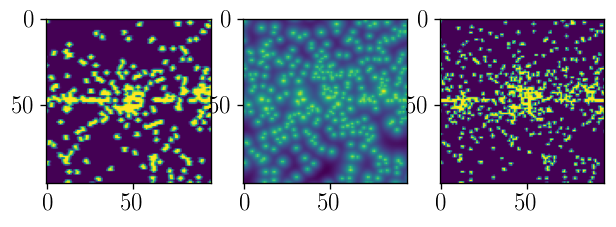

In [105]:
fig, axs = plt.subplots(1, 3)
axs[0].imshow((to_cart(d0)))
axs[1].imshow(np.log(to_cart(d1)))
axs[2].imshow((to_cart(d2)))

## B. Inspect NPModel

In [ ]:
from models.np_model import NPModel
from models.poisson_model import PoissonModel
from numpyro.infer.util import Predictive

In [ ]:
pmodel = NPModel(
    r_outer=25,
    l_max=2,
    vary_disk=True,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
    n_exp=1,
    debug_model=True
)

In [ ]:
numpyro.render_model(pmodel.model, model_args=(pmodel.data,), render_distributions=True)

In [ ]:
with numpyro.handlers.seed(rng_seed=234234):
    ll = pmodel.model(pmodel.data)

In [ ]:
Predictive(npmodel.model, num_samples=1, batch_ndims=0)(jax.random.PRNGKey(42), npmodel.data)